# MAIN_GRADIENT_TOWER_PIPELINE_AUDITED

Main notebook reorganized into autonomous blocks to run the audited modular pipeline: QC, BRN/MOST flows, NetCDF, figures, vertical profiles and flag auditing.


## 0. Project Routes

Always run first. Defines the main folders and files used by all blocks.

In [1]:
from pathlib import Path
import sys

PAPER_ROOT = Path(r"D:/OneDrive/PAPER_GRADIENT_TOWER")
PROJECT_ROOT = PAPER_ROOT / "gradient_tower_python_pipeline_modular"
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

DATA_ROOT = PAPER_ROOT / "PYTHON"
LATEX_GRAPHICS_DIR = PAPER_ROOT / "gradient_tower_python_pipeline_modular" / "graphics"

QC_NETCDF = DATA_ROOT / "data_nc/OGHYO_GradientTower_Dataset_2018_2026.nc"
MINUTE_FLUX_NETCDF = DATA_ROOT / "data_nc/OGHYO_Minute_Fluxes_2018_2026.nc"
FLUX_NETCDF = DATA_ROOT / "data_nc/OGHYO_30min_Fluxes_2018_2026.nc"

QC_NETCDF, MINUTE_FLUX_NETCDF, FLUX_NETCDF, LATEX_GRAPHICS_DIR

(WindowsPath('D:/OneDrive/PAPER_GRADIENT_TOWER/PYTHON/data_nc/OGHYO_GradientTower_Dataset_2018_2026.nc'),
 WindowsPath('D:/OneDrive/PAPER_GRADIENT_TOWER/PYTHON/data_nc/OGHYO_Minute_Fluxes_2018_2026.nc'),
 WindowsPath('D:/OneDrive/PAPER_GRADIENT_TOWER/PYTHON/data_nc/OGHYO_30min_Fluxes_2018_2026.nc'),
 WindowsPath('D:/OneDrive/PAPER_GRADIENT_TOWER/gradient_tower_python_pipeline_modular/graphics'))

## 1. Single Loading of Libraries and Functions

This is the notebook's only import block. If you edit `.py` files while the kernel is running, leave `RELOAD_LOCAL_MODULES = True`.

In [2]:
import importlib
import pandas as pd
import xarray as xr

RELOAD_LOCAL_MODULES = True

import gradient_tower_pipeline.qc_pipeline as qc_pipeline
import gradient_tower_pipeline.flux_pipeline as flux_pipeline
import gradient_tower_pipeline.flag_audit as flag_audit
import gradient_tower_pipeline.profile_plots as profile_plots
import gradient_tower_pipeline.qc_audit_figures as qc_audit_figures

if RELOAD_LOCAL_MODULES:
    importlib.reload(qc_pipeline)
    importlib.reload(flux_pipeline)
    importlib.reload(flag_audit)
    importlib.reload(profile_plots)
    importlib.reload(qc_audit_figures)

from gradient_tower_pipeline.qc_pipeline import (
    TowerConfig as QCTowerConfig,
    run_full_qc_pipeline,
)
from gradient_tower_pipeline.flux_pipeline import (
    FluxConfig,
    Flux30MinConfig,
    read_saved_tower_dataframes_from_netcdf,
    run_minute_flux_pipeline,
    run_30min_flux_pipeline,
    save_minute_energy_fluxes_to_netcdf,
    save_30min_energy_fluxes_to_netcdf,
    inspect_saved_flux_netcdf,
    generate_minute_flux_figures_and_statistics,
    generate_flux_figures_and_statistics,
    plot_qc_flag_diurnal_cycles,
    plot_seasonal_diurnal_fluxes,
)
from gradient_tower_pipeline.flag_audit import (
    make_default_tower_config,
    run_full_qc_audit_workflow,
    print_workflow_summary,
    print_qc_audit_report,
    audit_data_availability,
    save_reconstructed_dataframes_pickle,
)
from gradient_tower_pipeline.profile_plots import (
    VerticalProfileFigureConfig,
    run_vertical_profile_figure_workflow,
)
from gradient_tower_pipeline.qc_audit_figures import (
    QCAuditFigureConfig,
    audit_qc_audit_figure_outputs,
    generate_qc_audit_publication_figures,
)

print("Imports cargados correctamente")

Imports cargados correctamente


## 2. Central Execution Configuration

Modify the switches and general parameters here. The following blocks can be executed independently as long as their inputs already exist.

In [3]:
# QC
RUN_REGENERATE_QC = True
QC_STRICT_COLUMNS = True

# Carga de datos desde NetCDF QC
RUN_LOAD_QC_NETCDF = True

# C?lculo de flujos
RUN_MINUTE = True
RUN_30MIN = True
PROGRESS_MINUTE = True
PROGRESS_30MIN = True

# Estad?sticas internas del DataFrame 30 min
INCLUDE_30MIN_DISTRIBUTION_STATS = True
LOWER_30MIN_QUANTILE = 0.01
UPPER_30MIN_QUANTILE = 0.99

# Guardado NetCDF de flujos
SAVE_MINUTE_NETCDF = True
SAVE_30MIN_NETCDF = True
DROP_MINUTE_TEXT_LABELS = True
DROP_30MIN_TEXT_LABELS = True
VERIFY_NETCDF = True

# Figuras de flujos
SAVE_MINUTE_FIGURES = True
SAVE_30MIN_FIGURES = True
MINUTE_FIGURES_DIR = LATEX_GRAPHICS_DIR / "figures_flux_minute"
FIGURES_30MIN_DIR = LATEX_GRAPHICS_DIR / "figures_flux_30min"
SEASONAL_DIURNAL_FLUX_DIR = LATEX_GRAPHICS_DIR / "figures_flux_seasonal_diurnal"
SAVE_SEASONAL_DIURNAL_FLUX_FIGURES = True
FIGURES_START = None
FIGURES_END = None

# Perfiles verticales
RUN_VERTICAL_PROFILES = True
VERTICAL_PROFILE_FIGURES_DIR = LATEX_GRAPHICS_DIR
VERTICAL_PROFILE_MIN_AVAILABILITY = 0.80
VERTICAL_PROFILE_STRICT = False

# Auditor?a QC y figuras QC
RUN_QC_AUDIT = True
RUN_QC_AUDIT_FIGURES = True
QC_AUDIT_FIGURES_DIR = LATEX_GRAPHICS_DIR
QC_AUDIT_AVAILABILITY_THRESHOLD = 0.80
QC_AUDIT_TOP_N_COLUMNS = None
QC_AUDIT_SOURCE = "raw"
QC_AUDIT_TOP_K_COMBOS = 15
SAVE_QC_AUDIT_PICKLES = True
QC_AUDIT_OUTPUT_DIR = PROJECT_ROOT / "output_df"


## 3. QC Block: Regenerate Main NetCDF

Only run this block if you need to rebuild `QC_NETCDF` from original calibrations and MAT files. If `RUN_REGENERATE_QC = False`, it does nothing.

In [ ]:
qc_outputs = {}

if RUN_REGENERATE_QC:
    qc_cfg = QCTowerConfig(strict_columns=QC_STRICT_COLUMNS)
    raw_prepared, cleaned, flags, qc_summary, missing_summary = run_full_qc_pipeline(
        temp_calib_file=DATA_ROOT / "calib_txt/matrix_temp_met.dat",
        rh_calib_file=DATA_ROOT / "calib_txt/matrix_relhum_met.dat",
        tower_mat_file=DATA_ROOT / "input_mat/var_torre_30m_20180515_20260430.mat",
        sun_mat_file=DATA_ROOT / "input_mat/sun_position_20180515_20260430.mat",
        output_netcdf=QC_NETCDF,
        cfg=qc_cfg,
    )
    qc_outputs.update({
        "qc_cfg": qc_cfg,
        "raw_prepared": raw_prepared,
        "cleaned": cleaned,
        "flags": flags,
        "qc_summary": qc_summary,
        "missing_summary": missing_summary,
        "output_netcdf": QC_NETCDF,
    })
else:
    print("QC not regenerated. Using existing NetCDF:", QC_NETCDF)

qc_outputs.keys()

<frozen importlib._bootstrap>:241: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


NetCDF exportado correctamente: D:\OneDrive\PAPER_GRADIENT_TOWER\PYTHON\data_nc\OGHYO_GradientTower_Dataset_2018_2026.nc


dict_keys(['qc_cfg', 'raw_prepared', 'cleaned', 'flags', 'qc_summary', 'missing_summary', 'output_netcdf'])

## 4. Loading Block: Rebuild DataFrames from QC_NETCDF

This block loads the base DataFrames used by the flows, profiles, and audits.

In [ ]:
if RUN_LOAD_QC_NETCDF:
    cleaned_from_nc, flags_from_nc, raw_from_nc, ds, ds_raw = read_saved_tower_dataframes_from_netcdf(QC_NETCDF)
    print("cleaned_from_nc:", cleaned_from_nc.shape)
    print("flags_from_nc  :", flags_from_nc.shape)
    print("raw_from_nc    :", None if raw_from_nc is None else raw_from_nc.shape)
else:
    print("QC load omitted. Verify that cleaned_from_nc, flags_from_nc and raw_from_nc already exist in memory.")


cleaned_from_nc: (4186680, 22)
flags_from_nc  : (4186680, 12)
raw_from_nc    : (4186680, 21)


## 5. Calculation Block: Minute and 30-Minute Flows

This block only calculates flow DataFrames. It does not save files or generate figures.

In [6]:
pipeline_results = {}

if RUN_MINUTE:
    cfg_min = FluxConfig(progress=PROGRESS_MINUTE)
    flux_minute, summary_minute = run_minute_flux_pipeline(cleaned_from_nc, cfg_min, verbose=True)
    pipeline_results.update({
        "cfg_min": cfg_min,
        "flux_minute": flux_minute,
        "summary_minute": summary_minute,
    })
    print("flux_minute:", flux_minute.shape)

if RUN_30MIN:
    cfg30 = Flux30MinConfig(
        progress=PROGRESS_30MIN,
        include_distribution_stats=INCLUDE_30MIN_DISTRIBUTION_STATS,
        lower_quantile=LOWER_30MIN_QUANTILE,
        upper_quantile=UPPER_30MIN_QUANTILE,
    )
    flux_30m, report_30m = run_30min_flux_pipeline(cleaned_from_nc, cfg30, verbose=True)
    pipeline_results.update({
        "cfg30": cfg30,
        "flux_30m": flux_30m,
        "report_30m": report_30m,
    })
    print("flux_30m:", flux_30m.shape)

pipeline_results.keys()


--- 1. Minute pre-QC of input variables ---
Eligible MOST minute records: 2,936,770 of 4,186,680
Eligible BRN_ANC minute records: 2,936,770 of 4,186,680


MOST minute:   0%|          | 0/2936770 [00:00<?, ?it/s]


--- 2. Calculating minute MOST fluxes ---


BRN_ANC minute:   0%|          | 0/2936770 [00:00<?, ?it/s]


--- 3. Calculating minute anchored multi-layer BRN fluxes ---


...

BRN_ANC 30min:   0%|          | 0/107180 [00:00<?, ?it/s]


--- 3. Calculating 30-min BRN_ANC fluxes ---


BRN_ANC 30min: 100%|██████████| 107180/107180 [01:11<00:00, 1504.50it/s]



--- 4. Applying 30-min post-QC and final audit ---

--- 30-min flux report ---
Configuration:
  freq: 30min
  min_availability: 0.7
  heights_m: [2.0, 6.0, 12.0, 24.0]
  displacement_height_m: 0.5
  use_moist_air_density: True
  C_M: 0.08
  D_M: 2.4
  C_H: 0.2
  D_H: 12.0
  C_Q: 0.17
  D_Q: 20.0
  min_abs_q_diff: 1e-07
  most_tolerance_L_m: 0.05
  most_relative_tolerance: 0.001
  preserve_raw_outputs: True
  include_distribution_stats: True
  lower_quantile: 0.01
  upper_quantile: 0.99

Summary:
         total_records  pre_qc_rejected  eligible_for_calculation  valid_after_post_qc  post_qc_rejected_within_eligible  valid_pct_of_total  valid_pct_of_eligible
method                                                                                                                                                             
MOST            139556            32376                    107180                62079                             45101               44.48                  57.92
BRN_AN

dict_keys(['cfg_min', 'flux_minute', 'summary_minute', 'cfg30', 'flux_30m', 'report_30m'])

## 6. Saving Block: NetCDF for Flows

Saves the results calculated in the previous block. It can be run again without recalculating if `flux_minute` or `flux_30m` already exist in memory.

In [7]:
flux_save_results = {}

if SAVE_MINUTE_NETCDF and "flux_minute" in pipeline_results:
    output_nc_minute, ds_flux_minute, audit_flux_minute, name_map_minute = save_minute_energy_fluxes_to_netcdf(
        pipeline_results["flux_minute"],
        output_nc=MINUTE_FLUX_NETCDF,
        cfg=pipeline_results["cfg_min"],
        report={"summary": pipeline_results["summary_minute"]},
        timezone="America/Lima",
        expected_freq="1min",
        latitude=-12.04,
        longitude=-75.32,
        altitude_m=3315.0,
        engine="netcdf4",
        zlib=True,
        complevel=4,
        float_dtype="float32",
        save_audit_csv=True,
        save_audit_groups=True,
        overwrite=True,
        drop_text_labels=DROP_MINUTE_TEXT_LABELS,
    )
    flux_save_results.update({
        "output_nc_minute": output_nc_minute,
        "ds_flux_minute": ds_flux_minute,
        "audit_flux_minute": audit_flux_minute,
        "name_map_minute": name_map_minute,
    })
    if VERIFY_NETCDF:
        flux_save_results["ds_flux_minute_check"] = inspect_saved_flux_netcdf(output_nc_minute)

if SAVE_30MIN_NETCDF and "flux_30m" in pipeline_results:
    output_nc_30m, ds_flux_30m, audit_flux_30m, name_map_30m = save_30min_energy_fluxes_to_netcdf(
        pipeline_results["flux_30m"],
        output_nc=FLUX_NETCDF,
        cfg=pipeline_results["cfg30"],
        report=pipeline_results["report_30m"],
        timezone="America/Lima",
        expected_freq="30min",
        latitude=-12.04,
        longitude=-75.32,
        altitude_m=3315.0,
        engine="netcdf4",
        zlib=True,
        complevel=4,
        float_dtype="float32",
        save_audit_csv=True,
        save_audit_groups=True,
        overwrite=True,
        drop_text_labels=DROP_30MIN_TEXT_LABELS,
    )
    flux_save_results.update({
        "output_nc_30m": output_nc_30m,
        "ds_flux_30m": ds_flux_30m,
        "audit_flux_30m": audit_flux_30m,
        "name_map_30m": name_map_30m,
    })
    if VERIFY_NETCDF:
        flux_save_results["ds_flux_30m_check"] = inspect_saved_flux_netcdf(output_nc_30m)

flux_save_results.keys()



=== MINUTE NETCDF SAVED SUCCESSFULLY ===
File       : D:\OneDrive\PAPER_GRADIENT_TOWER\PYTHON\data_nc\OGHYO_Minute_Fluxes_2018_2026.nc
Time steps : 4186680
Variables  : 48
Audit CSV  : D:\OneDrive\PAPER_GRADIENT_TOWER\PYTHON\data_nc\OGHYO_Minute_Fluxes_2018_2026.audit.csv
Name map   : D:\OneDrive\PAPER_GRADIENT_TOWER\PYTHON\data_nc\OGHYO_Minute_Fluxes_2018_2026.column_name_map.csv

=== SAVED NETCDF SUMMARY ===
<xarray.Dataset> Size: 837MB
Dimensions:                (time: 4186680)
Coordinates:
  * time                   (time) datetime64[ns] 33MB 2018-05-15T14:00:00 ......
Data variables: (12/48)
    temp_n1                (time) float32 17MB ...
    temp_n2                (time) float32 17MB ...
    temp_n3                (time) float32 17MB ...
    temp_n5                (time) float32 17MB ...
    RH_n1                  (time) float32 17MB ...
    RH_n2                  (time) float32 17MB ...
    ...                     ...
    Ri_b_BRN_ANC           (time) float32 17MB ...
    St

dict_keys(['output_nc_minute', 'ds_flux_minute', 'audit_flux_minute', 'name_map_minute', 'ds_flux_minute_check', 'output_nc_30m', 'ds_flux_30m', 'audit_flux_30m', 'name_map_30m', 'ds_flux_30m_check'])

## 7. Flow Chart Block

Generates flow charts per minute and/or 30 minutes. Can be run independently if `pipeline_results` contains `flux_minute` or `flux_30m`.

In [8]:
def _load_flux_dataframe_for_figures(netcdf_path, label):
    """Carga un DataFrame de flujos desde NetCDF para generar figuras sin recalcular flujos."""
    path = Path(netcdf_path)
    if not path.exists():
        print(f"No se encontro el NetCDF de {label}: {path}")
        return None
    with xr.open_dataset(path) as ds:
        df = ds.to_dataframe()
    df = df.sort_index()
    print(f"{label} cargado desde NetCDF: {path} | shape={df.shape}")
    return df

if "pipeline_results" not in globals():
    pipeline_results = {}

if SAVE_MINUTE_FIGURES and "flux_minute" not in pipeline_results:
    flux_minute_from_nc = _load_flux_dataframe_for_figures(MINUTE_FLUX_NETCDF, "flux_minute")
    if flux_minute_from_nc is not None:
        pipeline_results["flux_minute"] = flux_minute_from_nc

if (SAVE_30MIN_FIGURES or SAVE_SEASONAL_DIURNAL_FLUX_FIGURES) and "flux_30m" not in pipeline_results:
    flux_30m_from_nc = _load_flux_dataframe_for_figures(FLUX_NETCDF, "flux_30m")
    if flux_30m_from_nc is not None:
        pipeline_results["flux_30m"] = flux_30m_from_nc

flux_figure_results = {}

if SAVE_MINUTE_FIGURES and "flux_minute" in pipeline_results:
    summary_stats_minute, comparison_stats_minute = generate_minute_flux_figures_and_statistics(
        pipeline_results["flux_minute"],
        out_dir=MINUTE_FIGURES_DIR,
        start=FIGURES_START,
        end=FIGURES_END,
        title_prefix="Minute ",
    )
    flux_figure_results["summary_stats_minute"] = summary_stats_minute
    flux_figure_results["comparison_stats_minute"] = comparison_stats_minute

if SAVE_30MIN_FIGURES and "flux_30m" in pipeline_results:
    summary_stats_30m, comparison_stats_30m = generate_flux_figures_and_statistics(
        pipeline_results["flux_30m"],
        out_dir=FIGURES_30MIN_DIR,
        start=FIGURES_START,
        end=FIGURES_END,
        title_prefix="30-min ",
    )
    flux_figure_results["summary_stats_30m"] = summary_stats_30m
    flux_figure_results["comparison_stats_30m"] = comparison_stats_30m

if SAVE_SEASONAL_DIURNAL_FLUX_FIGURES and "flux_30m" in pipeline_results:
    seasonal_diurnal_flux_stats = plot_seasonal_diurnal_fluxes(
        pipeline_results["flux_30m"],
        out_dir=SEASONAL_DIURNAL_FLUX_DIR,
        use_only_valid_qc=True,
        season_scheme="dry_wet",
        include_std_shading=True,
    )
    flux_figure_results["seasonal_diurnal_flux_stats"] = seasonal_diurnal_flux_stats

flux_figure_results.keys()


D:\OneDrive\PAPER_GRADIENT_TOWER\gradient_tower_python_pipeline_modular\src\gradient_tower_pipeline\flux_pipeline.py:2000: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
D:\OneDrive\PAPER_GRADIENT_TOWER\gradient_tower_python_pipeline_modular\src\gradient_tower_pipeline\flux_pipeline.py:2001: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(os.path.join(out_dir, f"{filename}.png"), bbox_inches="tight")
D:\OneDrive\PAPER_GRADIENT_TOWER\gradient_tower_python_pipeline_modular\src\gradient_tower_pipeline\flux_pipeline.py:2002: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(os.path.join(out_dir, f"{filename}.pdf"), bbox_inches="tight")
D:\OneDrive\PAPER_GRADIENT_TOWER\gradient_tower_python_pipeline_modular\src\gradient_tower_pipeline\flux_pipeline.py:2020: UserWarning: Creating legend with loc="best" can be slow with large amounts of

dict_keys(['summary_stats_minute', 'comparison_stats_minute', 'summary_stats_30m', 'comparison_stats_30m', 'seasonal_diurnal_flux_stats'])

## 8. Vertical Profile Block

Generates seasonal vertical profiles from `cleaned_from_nc`, without relying on flow calculations.

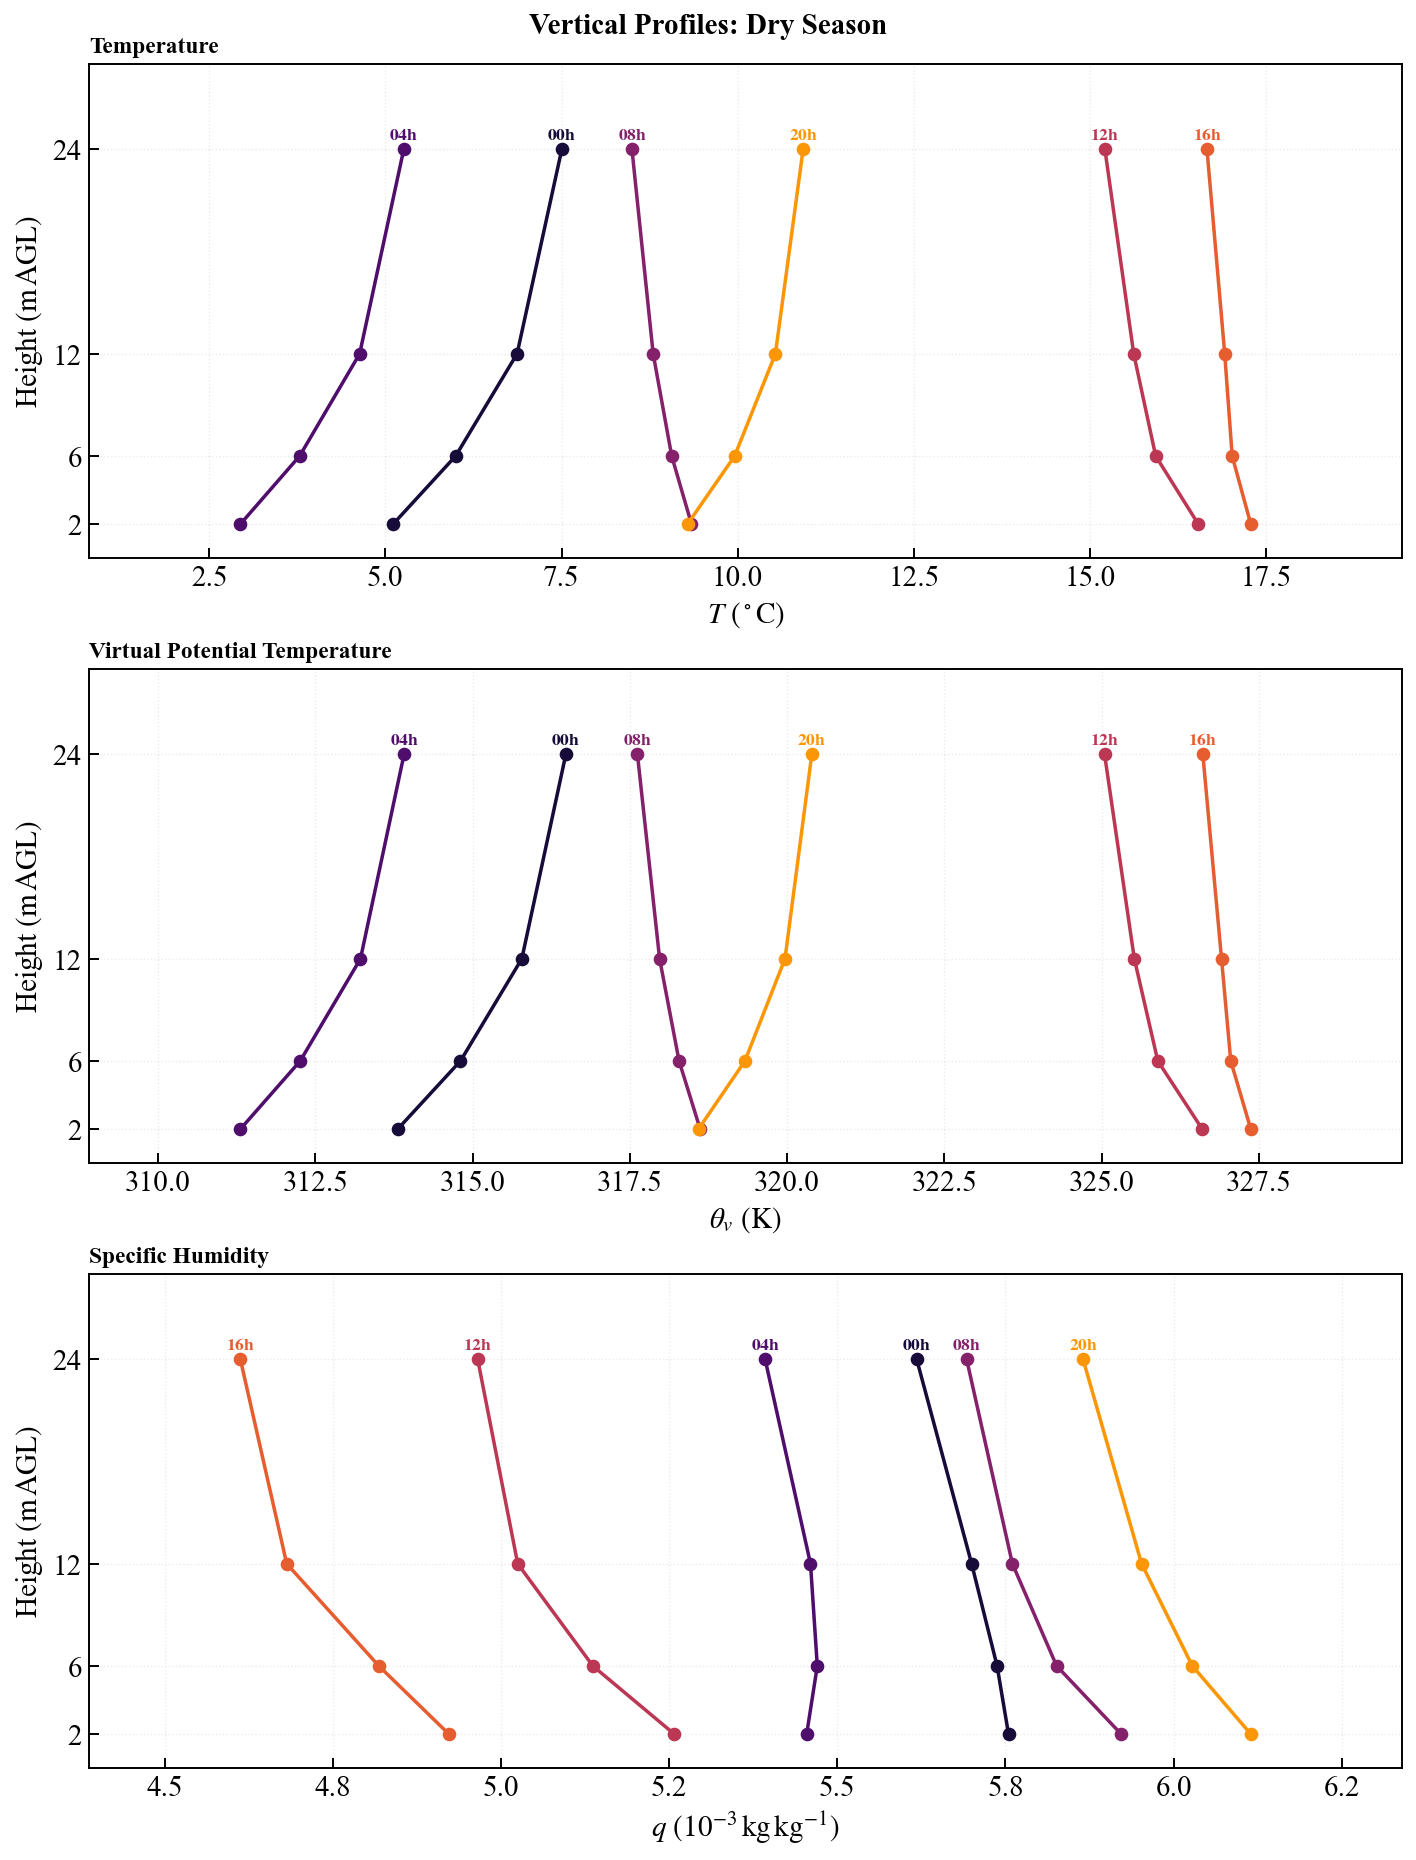

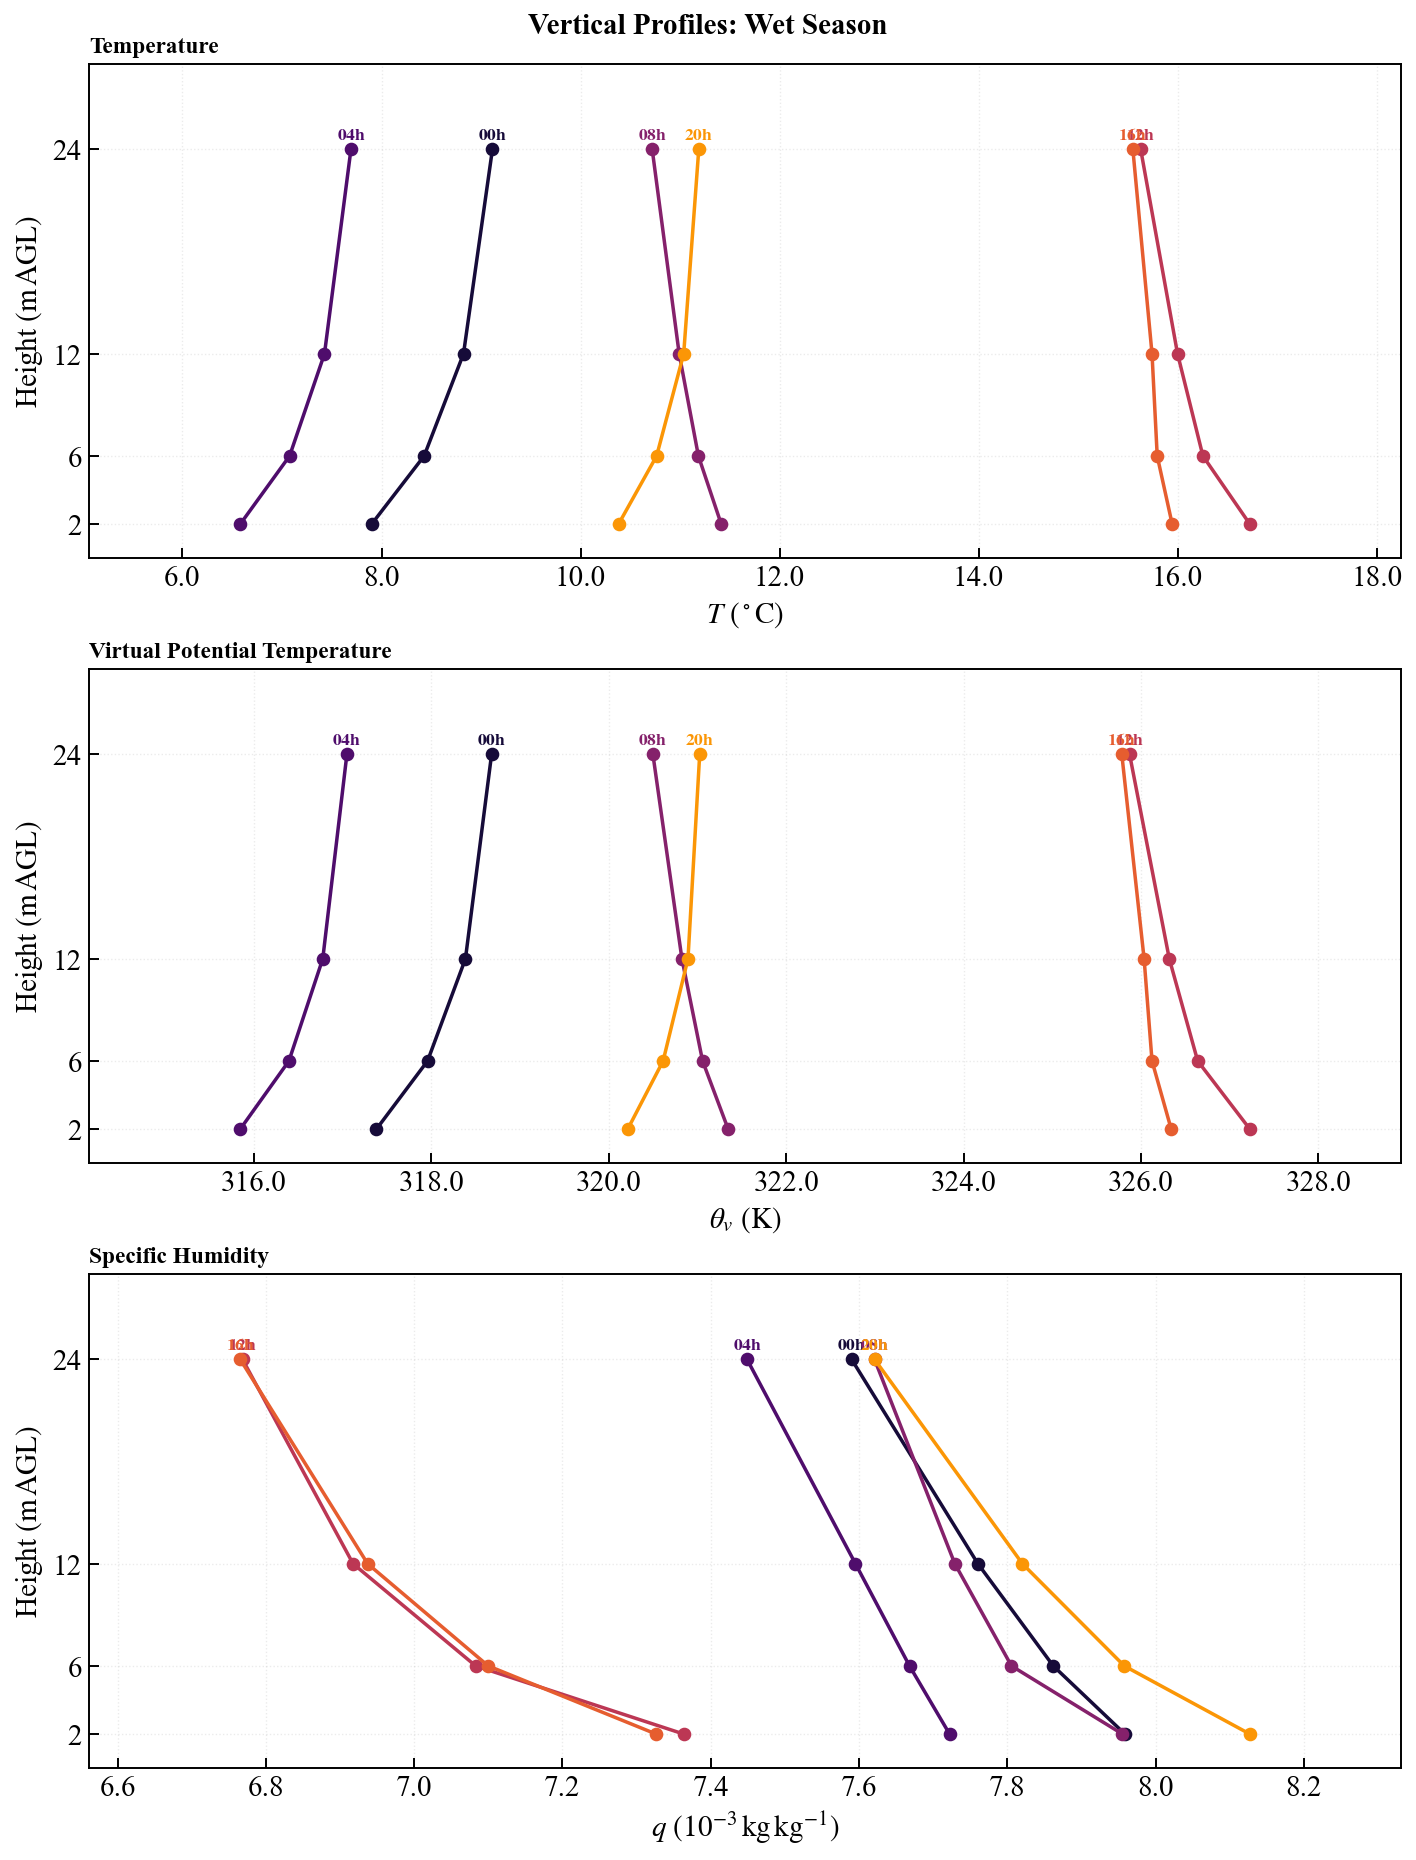

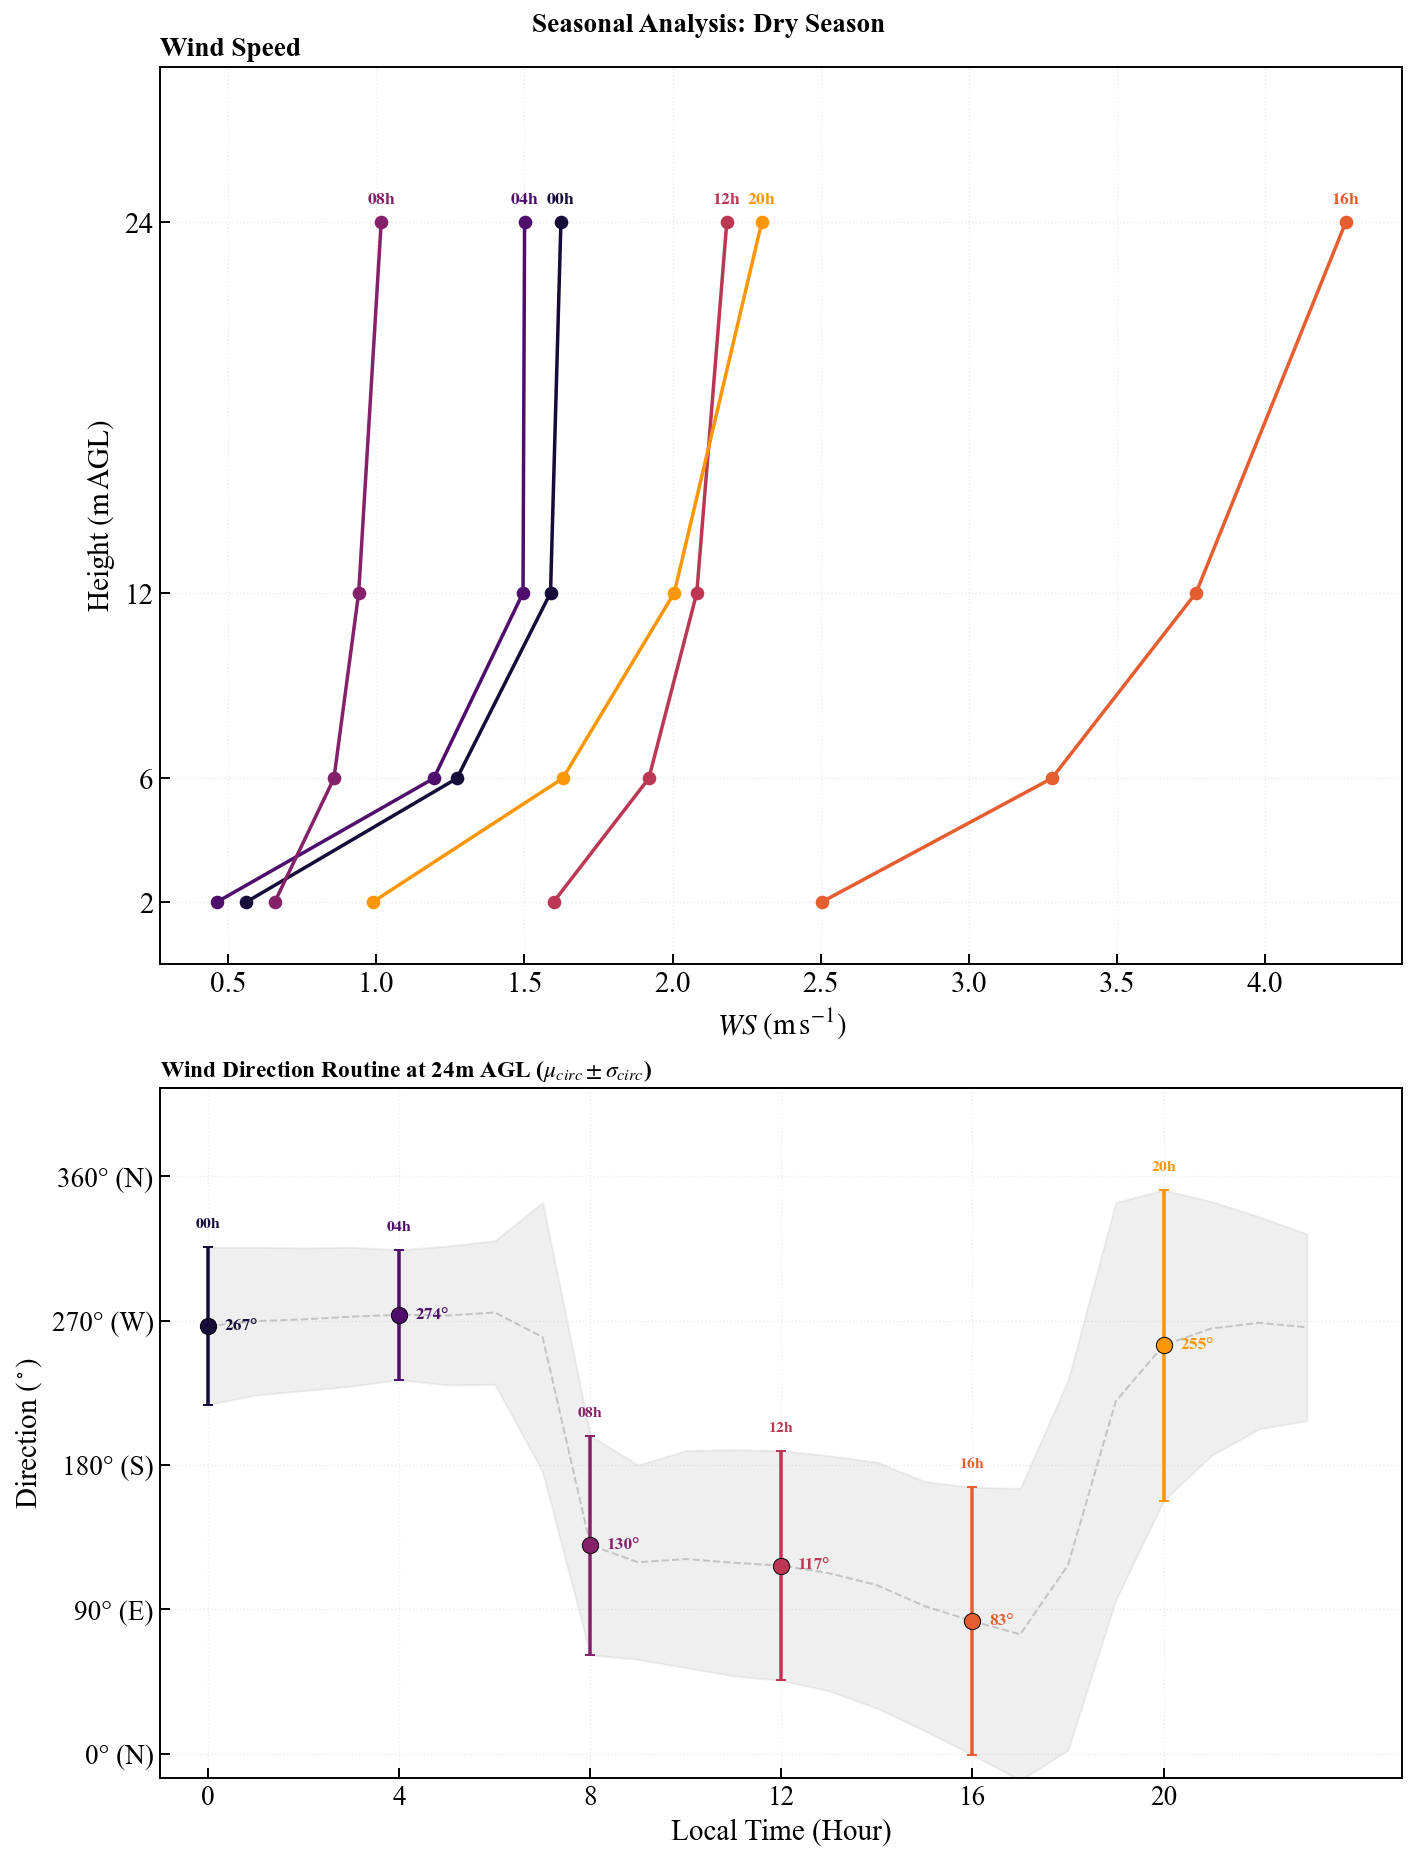

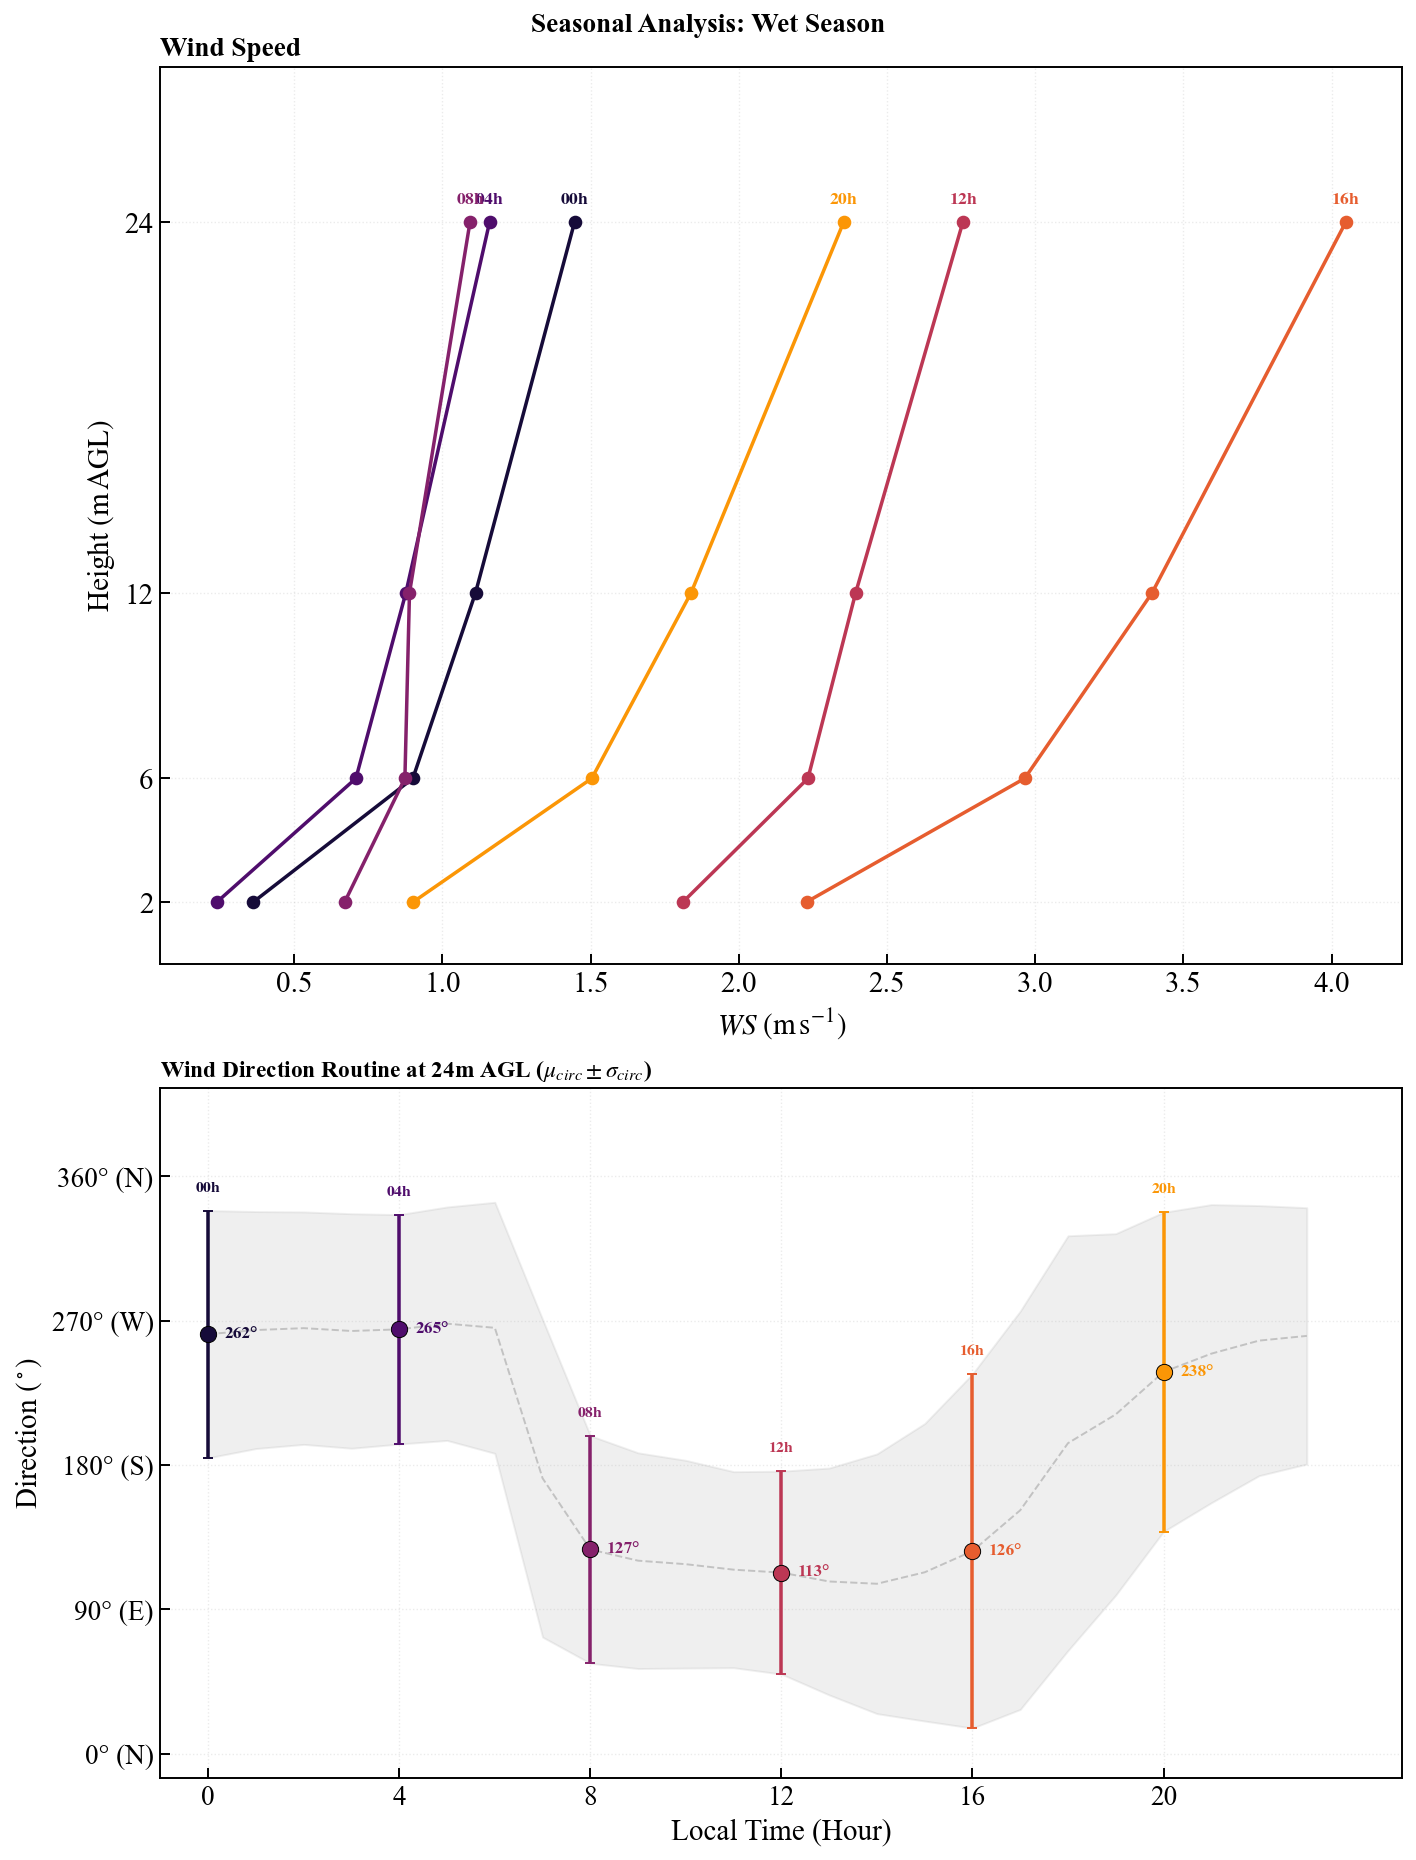

{'vertical_profile_audit':                            group  required_columns  present_columns  \
 0                    temperature                 4                4   
 1              relative_humidity                 4                4   
 2                     wind_speed                 4                4   
 3                 wind_direction                 1                1   
 4  virtual_potential_temperature                 4                4   
 5              specific_humidity                 4                4   
 6                 datetime_index                 0                1   
 
    min_valid_fraction  min_availability_required missing_columns status  
 0            0.901119                        0.8              []   PASS  
 1            0.911004                        0.8              []   PASS  
 2            0.916186                        0.8              []   PASS  
 3            0.914745                        0.8              []   PASS  
 4            0.90106

In [9]:
vertical_profile_results = {}

if RUN_VERTICAL_PROFILES:
    profile_fig_cfg = VerticalProfileFigureConfig(
        out_dir=VERTICAL_PROFILE_FIGURES_DIR,
        min_availability=VERTICAL_PROFILE_MIN_AVAILABILITY,
        generate_thermodynamic_profiles=True,
        generate_wind_profiles=True,
    )
    vertical_profile_audit, vertical_profile_paths = run_vertical_profile_figure_workflow(
        cleaned_from_nc,
        figure_cfg=profile_fig_cfg,
        strict=VERTICAL_PROFILE_STRICT,
    )
    vertical_profile_results["vertical_profile_audit"] = vertical_profile_audit
    vertical_profile_results["vertical_profile_paths"] = vertical_profile_paths

vertical_profile_results


## 9. QC Audit Block and QC Figures

Performs flag audits from `QC_NETCDF` and optionally generates QC figures for LaTeX.


=== cleaned_from_nc ===
shape: (4186680, 22)
index tz: None
duplicated times: 0
time range: 2018-05-15 14:00:00 to 2026-04-30 23:59:00
columns: ['temp_n1', 'temp_n2', 'temp_n3', 'temp_n5', 'RH_n1', 'RH_n2', 'RH_n3', 'RH_n5', 'wind_n1', 'wind_n2', 'wind_n3', 'wind_n5', 'dir_wind', 'q_2', 'q_6', 'q_12', 'q_24', 'theta_v_2', 'theta_v_6', 'theta_v_12', 'theta_v_24', 'P_Pa']

=== flags_from_nc ===
shape: (4186680, 13)
index tz: None
duplicated times: 0
time range: 2018-05-15 14:00:00 to 2026-04-30 23:59:00
columns: ['temp_n1', 'temp_n2', 'temp_n3', 'temp_n5', 'RH_n1', 'RH_n2', 'RH_n3', 'RH_n5', 'wind_n1', 'wind_n2', 'wind_n3', 'wind_n5', 'dir_wind']

=== raw_from_nc ===
shape: (4186680, 21)
index tz: None
duplicated times: 0
time range: 2018-05-15 14:00:00 to 2026-04-30 23:59:00
columns: ['zenith_tower', 'azimuth_tower', 'dir_wind', 'temp_n1', 'RH_n1', 'wind_n1', 'temp_n2', 'RH_n2', 'wind_n2', 'temp_n3', 'RH_n3', 'wind_n3', 'temp_n4', 'RH_n4', 'wind_n4', 'temp_n5', 'RH_n5', 'wind_n5', 'tem

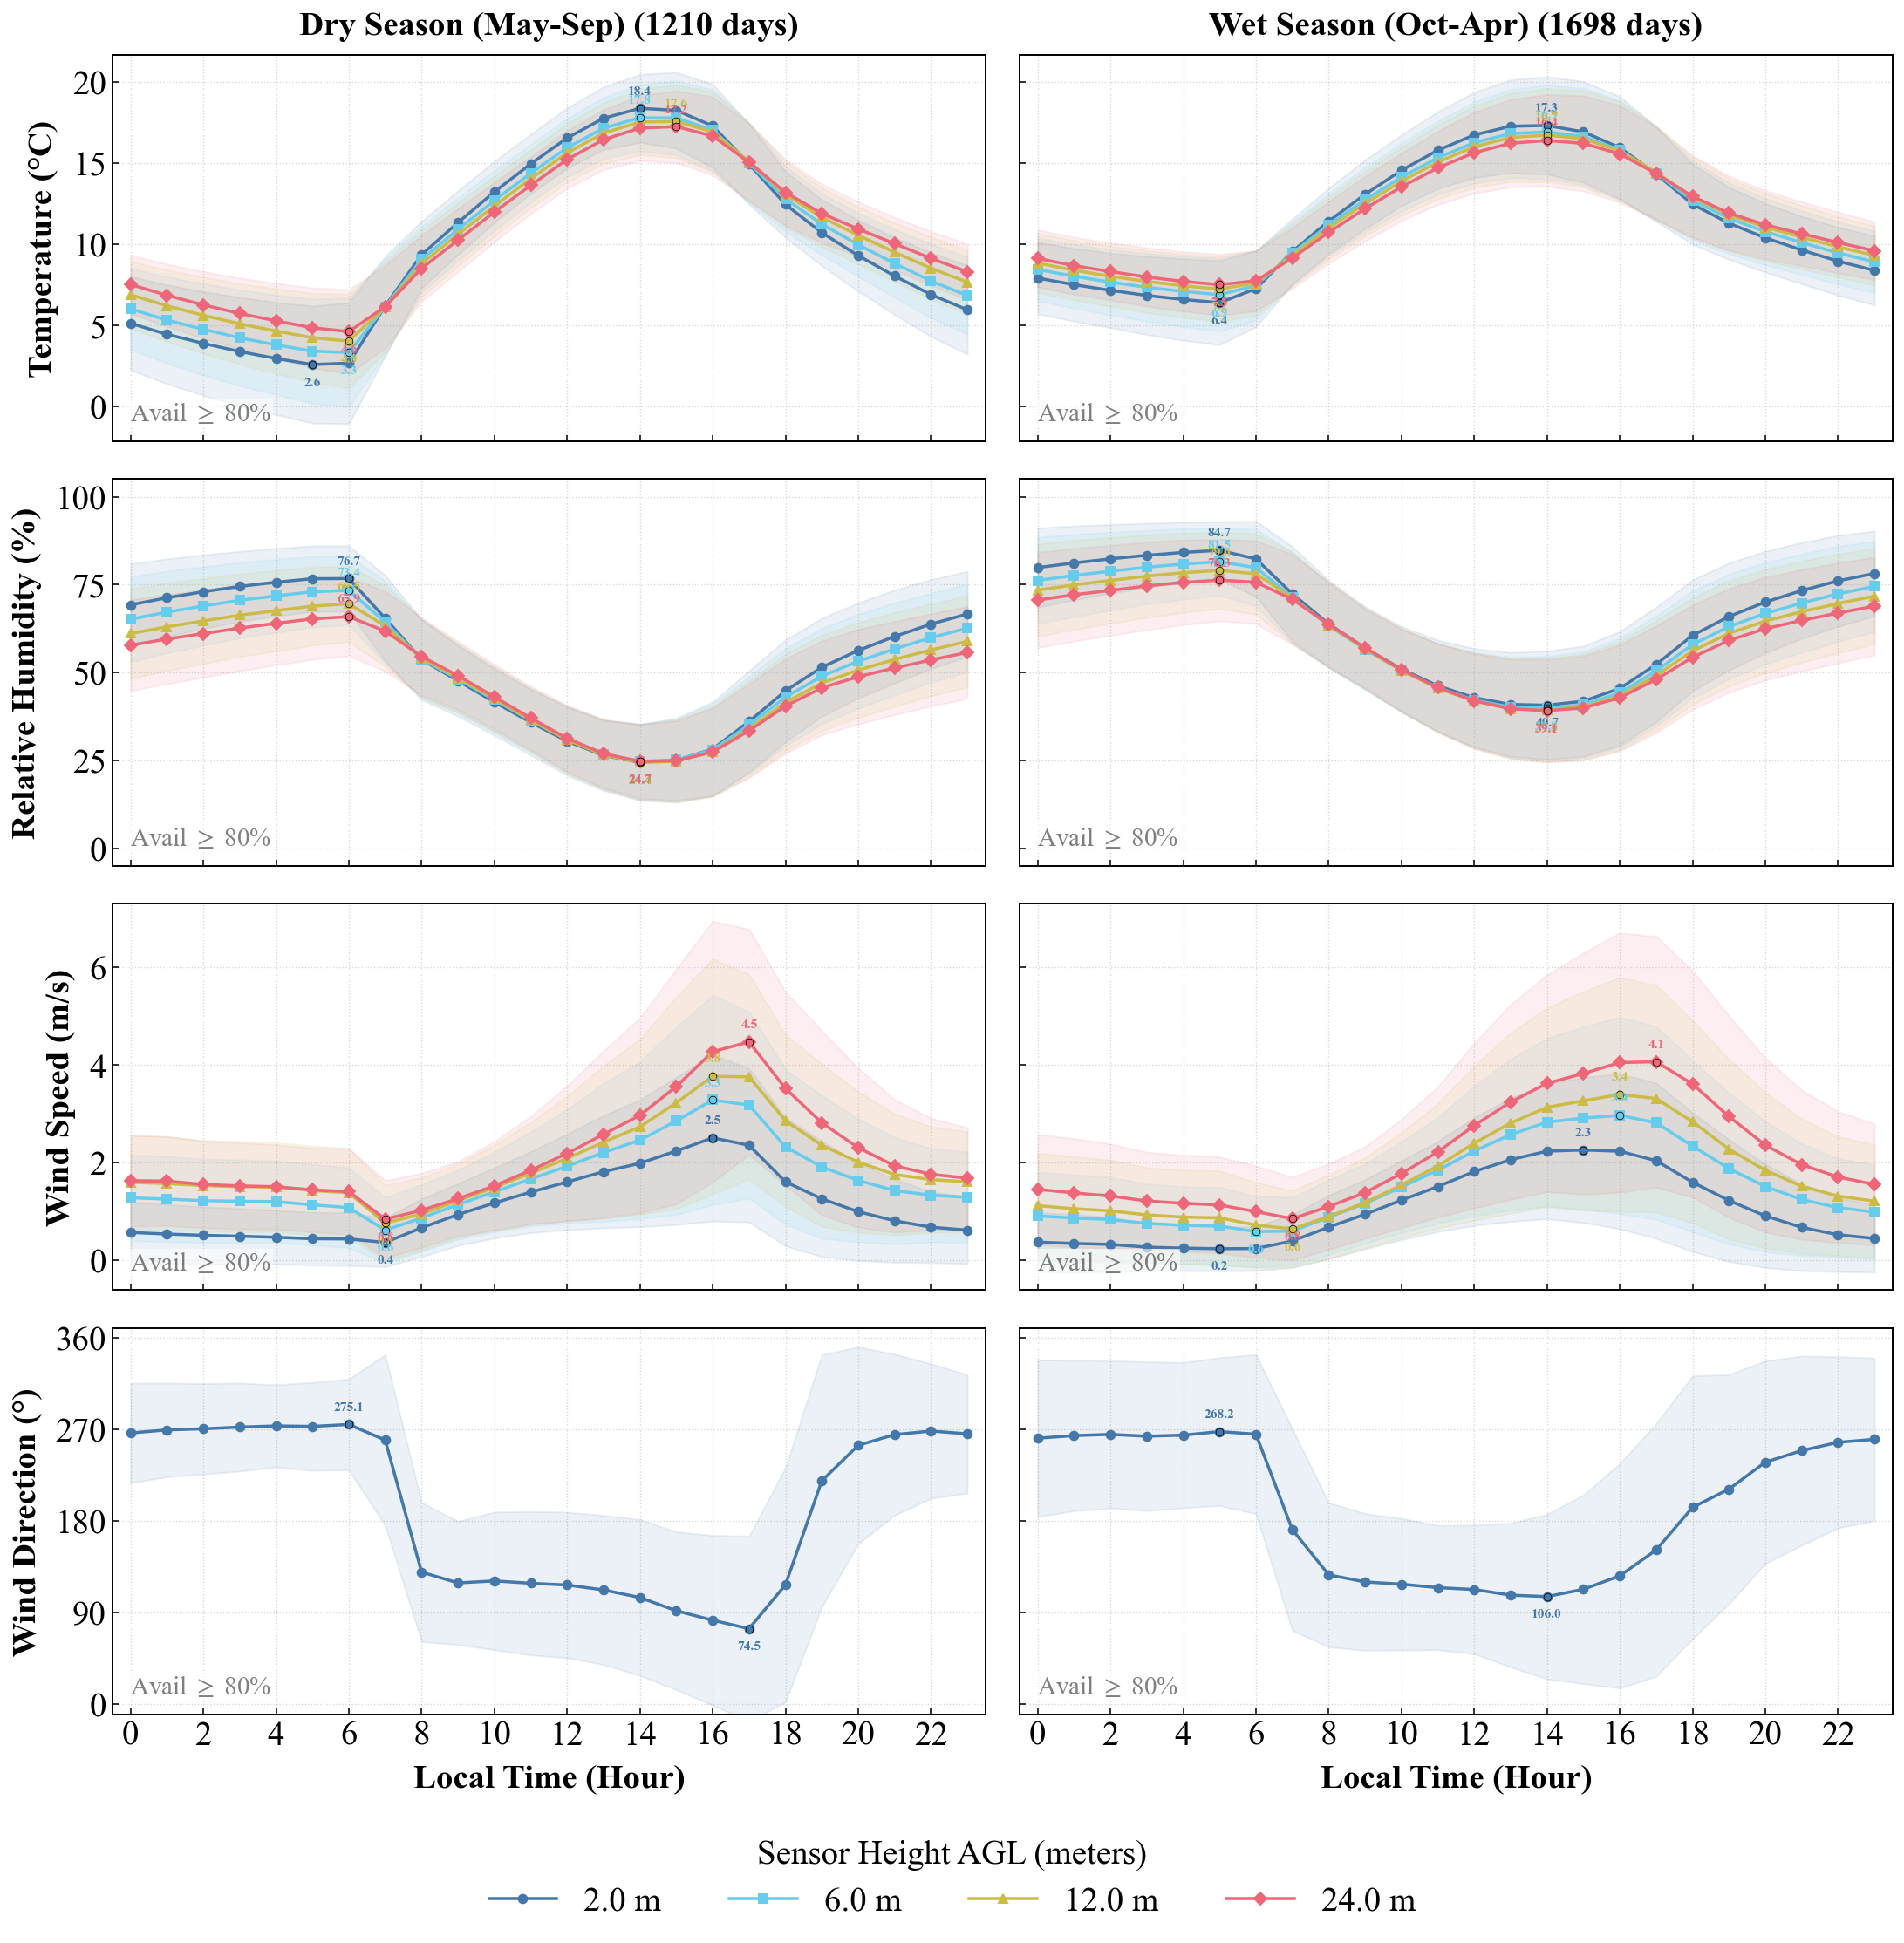

dict_keys(['audit_cfg', 'audit_results', 'availability_df', 'qc_audit_pickle_outputs', 'qc_audit_figure_paths', 'qc_audit_figure_check'])

In [10]:
qc_audit_results = {}

if RUN_QC_AUDIT:
    audit_cfg = make_default_tower_config()
    audit_results = run_full_qc_audit_workflow(
        QC_NETCDF,
        cfg=audit_cfg,
        audit_data_source=QC_AUDIT_SOURCE,
        top_k_combos=QC_AUDIT_TOP_K_COMBOS,
    )
    print_workflow_summary(audit_results)
    availability_df = audit_data_availability(
        audit_results["cleaned_from_nc"],
        audit_cfg,
        threshold=QC_AUDIT_AVAILABILITY_THRESHOLD,
    )

    qc_audit_results.update({
        "audit_cfg": audit_cfg,
        "audit_results": audit_results,
        "availability_df": availability_df,
    })

    if SAVE_QC_AUDIT_PICKLES:
        qc_audit_pickle_outputs = save_reconstructed_dataframes_pickle(
            cleaned_from_nc=audit_results["cleaned_from_nc"],
            flags_from_nc=audit_results["flags_from_nc"],
            raw_from_nc=audit_results.get("raw_from_nc"),
            out_dir=str(QC_AUDIT_OUTPUT_DIR),
        )
        qc_audit_results["qc_audit_pickle_outputs"] = qc_audit_pickle_outputs

    if RUN_QC_AUDIT_FIGURES:
        qc_figure_cfg = QCAuditFigureConfig(
            out_dir=QC_AUDIT_FIGURES_DIR,
            availability_threshold=QC_AUDIT_AVAILABILITY_THRESHOLD,
            top_n_columns=QC_AUDIT_TOP_N_COLUMNS,
        )
        qc_audit_figure_paths = generate_qc_audit_publication_figures(
            audit_results,
            cfg=audit_cfg,
            figure_cfg=qc_figure_cfg,
        )
        qc_audit_figure_check = audit_qc_audit_figure_outputs(qc_figure_cfg)
        qc_audit_results["qc_audit_figure_paths"] = qc_audit_figure_paths
        qc_audit_results["qc_audit_figure_check"] = qc_audit_figure_check

qc_audit_results.keys()


## 10. Final Audit of Expected Products

This block verifies that the main script has generated the expected files and graphs. It does not recalculate products; it only audits paths and sizes.

In [11]:
def _file_record(label, path, required=True):
    p = Path(path)
    return {
        "product": label,
        "path": str(p),
        "required": bool(required),
        "exists": p.exists(),
        "size_bytes": p.stat().st_size if p.exists() else 0,
        "status": "PASS" if p.exists() and p.stat().st_size > 0 else ("MISSING" if required else "OPTIONAL"),
    }

expected_products = []

# NetCDF QC y flujos
expected_products.append(_file_record("QC NetCDF", QC_NETCDF, required=True))
if SAVE_MINUTE_NETCDF:
    expected_products.extend([
        _file_record("Minute flux NetCDF", MINUTE_FLUX_NETCDF),
        _file_record("Minute flux audit CSV", MINUTE_FLUX_NETCDF.with_suffix(".audit.csv")),
        _file_record("Minute flux column map CSV", MINUTE_FLUX_NETCDF.with_suffix(".column_name_map.csv")),
    ])
if SAVE_30MIN_NETCDF:
    expected_products.extend([
        _file_record("30-min flux NetCDF", FLUX_NETCDF),
        _file_record("30-min flux audit CSV", FLUX_NETCDF.with_suffix(".audit.csv")),
        _file_record("30-min flux column map CSV", FLUX_NETCDF.with_suffix(".column_name_map.csv")),
    ])

# Figuras est?ndar de flujos
standard_flux_files = [
    "timeseries_QH", "timeseries_QE", "timeseries_ustar",
    "scatter_QH", "scatter_QE", "scatter_ustar",
    "diurnal_QH", "diurnal_QE", "diurnal_ustar",
    "qc_distribution_Input_QC_Flag", "qc_distribution_QC_Flag_MOST", "qc_distribution_QC_Flag_BRN_ANC",
]
for out_dir, prefix, enabled in [
    (MINUTE_FIGURES_DIR, "Minute", SAVE_MINUTE_FIGURES),
    (FIGURES_30MIN_DIR, "30-min", SAVE_30MIN_FIGURES),
]:
    if enabled:
        for stem in standard_flux_files:
            expected_products.append(_file_record(f"{prefix} figure {stem}.png", Path(out_dir) / f"{stem}.png"))
            expected_products.append(_file_record(f"{prefix} figure {stem}.pdf", Path(out_dir) / f"{stem}.pdf"))
        for qc_col in ["Input_QC_Flag", "QC_Flag_MOST", "QC_Flag_BRN_ANC"]:
            expected_products.append(_file_record(f"{prefix} QC diurnal heatmap {qc_col}.png", Path(out_dir) / f"qc_diurnal_counts_{qc_col}.png"))
            expected_products.append(_file_record(f"{prefix} QC diurnal heatmap {qc_col}.pdf", Path(out_dir) / f"qc_diurnal_counts_{qc_col}.pdf"))
            expected_products.append(_file_record(f"{prefix} QC diurnal stacked {qc_col}.png", Path(out_dir) / f"qc_diurnal_stacked_{qc_col}.png"))
            expected_products.append(_file_record(f"{prefix} QC diurnal stacked {qc_col}.pdf", Path(out_dir) / f"qc_diurnal_stacked_{qc_col}.pdf"))
            expected_products.append(_file_record(f"{prefix} QC diurnal table {qc_col}.csv", Path(out_dir) / f"qc_diurnal_counts_{qc_col}.csv"))
        expected_products.append(_file_record(f"{prefix} flux summary CSV", Path(out_dir) / "flux_summary_statistics.csv"))
        expected_products.append(_file_record(f"{prefix} flux comparison CSV", Path(out_dir) / "flux_comparison_statistics.csv"))

# Figuras estacionales diurnas de flujos
if SAVE_SEASONAL_DIURNAL_FLUX_FIGURES:
    for stem in ["seasonal_diurnal_QH", "seasonal_diurnal_QE", "seasonal_diurnal_ustar"]:
        expected_products.append(_file_record(f"Seasonal diurnal {stem}.png", SEASONAL_DIURNAL_FLUX_DIR / f"{stem}.png"))
        expected_products.append(_file_record(f"Seasonal diurnal {stem}.pdf", SEASONAL_DIURNAL_FLUX_DIR / f"{stem}.pdf"))
        expected_products.append(_file_record(f"Seasonal diurnal {stem}_statistics.csv", SEASONAL_DIURNAL_FLUX_DIR / f"{stem}_statistics.csv"))

# Perfiles verticales
if RUN_VERTICAL_PROFILES:
    for filename in [
        "seasonal_profile_dry_season.png",
        "seasonal_profile_wet_season.png",
        "seasonal_wind_dry_season.png",
        "seasonal_wind_wet_season.png",
    ]:
        expected_products.append(_file_record(f"Vertical profile {filename}", VERTICAL_PROFILE_FIGURES_DIR / filename))

# Auditor?a QC: pickles y figuras
if RUN_QC_AUDIT and SAVE_QC_AUDIT_PICKLES:
    for filename in ["cleaned_from_nc.pkl", "flags_from_nc.pkl", "raw_from_nc.pkl"]:
        expected_products.append(_file_record(f"QC audit pickle {filename}", QC_AUDIT_OUTPUT_DIR / filename, required=False))

if RUN_QC_AUDIT and RUN_QC_AUDIT_FIGURES:
    for filename in [
        "qc_flags_composition_ranked.png",
        "bars_qc_outcome_stacked_100pct.png",
        "diurnal_cycle_validated_with_wdir.png",
    ]:
        expected_products.append(_file_record(f"QC audit figure {filename}", QC_AUDIT_FIGURES_DIR / filename))

output_manifest = pd.DataFrame(expected_products)
missing_required = output_manifest[(output_manifest["required"]) & (output_manifest["status"] != "PASS")]
print(f"Productos auditados: {len(output_manifest)}")
print(f"Faltantes requeridos: {len(missing_required)}")
output_manifest


Productos auditados: 108
Faltantes requeridos: 0


,product,path,required,exists,size_bytes,status
0,QC NetCDF,D:\OneDrive\PAPER_GRADIENT_TOWER\PYTHON\data_n...,True,True,1219559649,PASS
1,Minute flux NetCDF,D:\OneDrive\PAPER_GRADIENT_TOWER\PYTHON\data_n...,True,True,345002355,PASS
2,Minute flux audit CSV,D:\OneDrive\PAPER_GRADIENT_TOWER\PYTHON\data_n...,True,True,945,PASS
3,Minute flux column map CSV,D:\OneDrive\PAPER_GRADIENT_TOWER\PYTHON\data_n...,True,True,1233,PASS
4,30-min flux NetCDF,D:\OneDrive\PAPER_GRADIENT_TOWER\PYTHON\data_n...,True,True,29680047,PASS
...,...,...,...,...,...,...
103,QC audit pickle flags_from_nc.pkl,D:\OneDrive\PAPER_GRADIENT_TOWER\gradient_towe...,False,True,251201992,PASS
104,QC audit pickle raw_from_nc.pkl,D:\OneDrive\PAPER_GRADIENT_TOWER\gradient_towe...,False,True,736856959,PASS
105,QC audit figure qc_flags_composition_ranked.png,D:\OneDrive\PAPER_GRADIENT_TOWER\gradient_towe...,True,True,345080,PASS
106,QC audit figure bars_qc_outcome_stacked_100pct...,D:\OneDrive\PAPER_GRADIENT_TOWER\gradient_towe...,True,True,366135,PASS


## 11. Optional Integrated Execution

This block allows all the main blocks to run in order from a single function. It is optional; the previous blocks are recommended for standalone execution.

In [ ]:
def run_complete_pipeline() -> dict:
    """Execute the complete pipeline using the global configuration variables from the notebook."""
    out = {}

    loaded = read_saved_tower_dataframes_from_netcdf(QC_NETCDF)
    cleaned_local, flags_local, raw_local, ds_local, ds_raw_local = loaded
    out.update({
        "cleaned_from_nc": cleaned_local,
        "flags_from_nc": flags_local,
        "raw_from_nc": raw_local,
        "ds": ds_local,
        "ds_raw": ds_raw_local,
    })

    if RUN_MINUTE:
        cfg_min_local = FluxConfig(progress=PROGRESS_MINUTE)
        flux_minute_local, summary_minute_local = run_minute_flux_pipeline(cleaned_local, cfg_min_local, verbose=True)
        out.update({"cfg_min": cfg_min_local, "flux_minute": flux_minute_local, "summary_minute": summary_minute_local})

    if RUN_30MIN:
        cfg30_local = Flux30MinConfig(
            progress=PROGRESS_30MIN,
            include_distribution_stats=INCLUDE_30MIN_DISTRIBUTION_STATS,
            lower_quantile=LOWER_30MIN_QUANTILE,
            upper_quantile=UPPER_30MIN_QUANTILE,
        )
        flux_30m_local, report_30m_local = run_30min_flux_pipeline(cleaned_local, cfg30_local, verbose=True)
        out.update({"cfg30": cfg30_local, "flux_30m": flux_30m_local, "report_30m": report_30m_local})

    return out

# To execute everything in a single call:
# integrated_results = run_complete_pipeline()
